<a href="https://colab.research.google.com/github/rubycm01/Proyecto_2_AP/blob/main/3_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import requests

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_name,discoverymethod,disc_facility,pl_rade,pl_eqt,st_teff+from+ps+where+pl_rade+is+not+null+and+pl_eqt+is+not+null&format=csv"

# Descarga y guarda en un solo paso
open("exoplanetas_bruto.csv", "wb").write(requests.get(url).content)

1102473

In [9]:
import pandas as pd
import numpy as np

In [10]:
import sqlite3

df = pd.read_csv('exoplanetas_bruto.csv')

# Crear la conexión a la base de datos (se crea el archivo si no existe)
conexion = sqlite3.connect('sistemas_planetarios.db')

# Guardar los datos del DataFrame en una tabla llamada 'planetas'
df.to_sql('planetas', conexion, if_exists='replace', index=False)

# Cerrar la conexión
conexion.close()

## 2) Cálculo Estadístico (promedio)

In [11]:
# Volvemos a abrir la conexión (si ya la había cerrado)
conexion = sqlite3.connect('sistemas_planetarios.db')

# Escribimos la consulta SQL
consulta_sql = """
SELECT discoverymethod, AVG(pl_rade) as radio_promedio
FROM planetas
GROUP BY discoverymethod
"""

# Ejecutamos la consulta usando Pandas para que se vea ordenado
promedio = pd.read_sql_query(consulta_sql, conexion)

# Imprimimos el resultado en la consola
print(promedio)

                 discoverymethod  radio_promedio
0                        Imaging       19.600236
1  Orbital Brightness Modulation       13.247917
2                Radial Velocity        5.513865
3                        Transit        6.118718
4      Transit Timing Variations        3.042549


## El Filtro de Habitabilida

In [12]:
# Volvemos a abrir la conexión
conexion = sqlite3.connect('sistemas_planetarios.db')

# consulta sql
consulta_habitabilidad = """
SELECT *
FROM planetas
WHERE pl_eqt BETWEEN 200 AND 320
  AND pl_rade < 2.5
"""

# ejecutar la consulta y guardarla en un nuevo DataFrame
mundos_habitables = pd.read_sql_query(consulta_habitabilidad, conexion)


print(mundos_habitables)

           pl_name discoverymethod  \
0       TOI-2095 c         Transit   
1    Kepler-1389 b         Transit   
2     Kepler-438 b         Transit   
3     Kepler-296 e         Transit   
4    Kepler-1540 b         Transit   
..             ...             ...   
303   Kepler-436 b         Transit   
304   Kepler-436 b         Transit   
305   Kepler-993 b         Transit   
306  Kepler-1058 b         Transit   
307   Kepler-991 b         Transit   

                                    disc_facility   pl_rade  pl_eqt  st_teff  
0    Transiting Exoplanet Survey Satellite (TESS)  1.447525  300.66   3746.0  
1                                          Kepler  1.770000  318.00   5129.0  
2                                          Kepler  0.970000  288.00   3749.0  
3                                          Kepler  1.080000  244.00   3517.0  
4                                          Kepler  2.300000  238.00   4366.0  
..                                            ...       ...     ...  

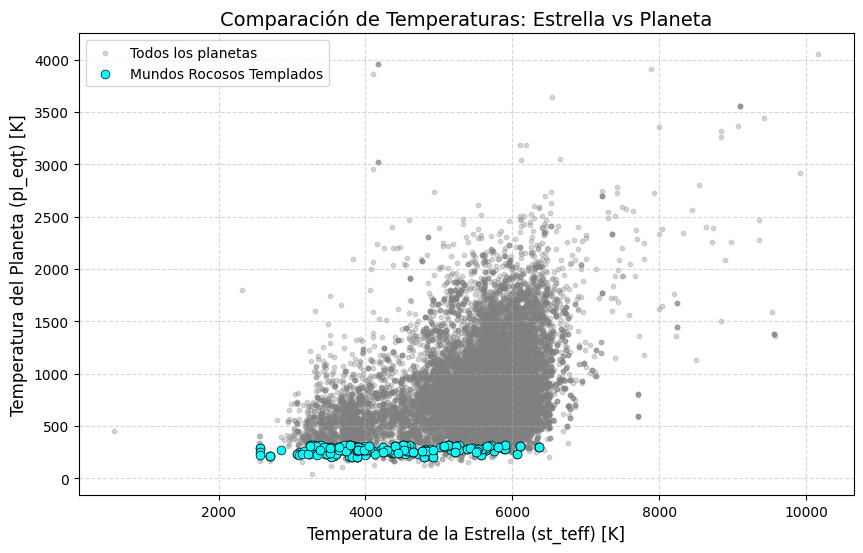

In [13]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# 2. Graficar TODOS los planetas (el fondo gris)
# Usamos 'alpha=0.3' para que sean semitransparentes y no tapen a los otros
plt.scatter(df['st_teff'], df['pl_eqt'],
            color='gray',
            alpha=0.3,
            label='Todos los planetas',
            s=10) # 's' es el tamaño del punto

# 3. Superponer los planetas habitables (en azul brillante)
plt.scatter(mundos_habitables['st_teff'], mundos_habitables['pl_eqt'],
            color='cyan',
            label='Mundos Rocosos Templados',
            edgecolor='black', # Un borde negro para que resalten más
            linewidth=0.5,
            s=40)

# 4. Personalizar la gráfica
plt.title('Comparación de Temperaturas: Estrella vs Planeta', fontsize=14)
plt.xlabel('Temperatura de la Estrella (st_teff) [K]', fontsize=12)
plt.ylabel('Temperatura del Planeta (pl_eqt) [K]', fontsize=12)
plt.legend() # Muestra el cuadro explicativo de los colores
plt.grid(True, linestyle='--', alpha=0.5) # Añade una cuadrícula suave

# 5. Mostrar la gráfica
plt.show()